In [26]:
import pandas as pd

In [27]:
train_df = pd.read_csv('../results/outputs/Selected/train_rf_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_rf_top10_features.csv')

In [28]:
train_df_en = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df_en = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [29]:
train_df.head()

,blood_pressure,social_score,anxiety_level,basic_needs,academic_performance,self_esteem,depression,social_support,physical_score,bullying,target
0,-1.430923,0.013938,0.314428,0.147712,0.152196,0.795832,-0.333345,0.118375,-0.682160,-0.413484,1
1,0.979053,0.967443,1.282463,-0.540048,-1.265078,-0.771658,1.611905,-0.837312,0.652823,1.549820,2
2,-0.225935,-0.437439,-1.621643,0.835473,0.860833,0.795832,-1.241128,1.074062,-0.252892,-1.067918,0
3,0.979053,0.792533,0.637107,-0.540048,-1.265078,-0.883621,0.574438,-0.837312,0.652823,1.549820,2
4,-0.225935,-0.436458,-0.653607,0.835473,0.860833,1.019759,-1.630178,1.074062,-0.235895,-1.067918,0


In [30]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   blood_pressure        880 non-null    float64
 1   social_score          880 non-null    float64
 2   anxiety_level         880 non-null    float64
 3   basic_needs           880 non-null    float64
 4   academic_performance  880 non-null    float64
 5   self_esteem           880 non-null    float64
 6   depression            880 non-null    float64
 7   social_support        880 non-null    float64
 8   physical_score        880 non-null    float64
 9   bullying              880 non-null    float64
 10  target                880 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 75.8 KB


In [31]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   blood_pressure        220 non-null    float64
 1   social_score          220 non-null    float64
 2   anxiety_level         220 non-null    float64
 3   basic_needs           220 non-null    float64
 4   academic_performance  220 non-null    float64
 5   self_esteem           220 non-null    float64
 6   depression            220 non-null    float64
 7   social_support        220 non-null    float64
 8   physical_score        220 non-null    float64
 9   bullying              220 non-null    float64
 10  target                220 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 19.0 KB


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [34]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        74
           1       0.85      0.93      0.89        72
           2       0.88      0.88      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [35]:
#With all features

In [36]:
feature_cols_en = [c for c in train_df_en.columns if c != "target"]

X_train_en = train_df_en[feature_cols_en]
y_train_en = train_df_en["target"]

x_test_en = test_df_en[feature_cols_en]
y_test_en = test_df_en["target"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_en, y_train_en)

rf_preds_en = rf.predict(x_test_en)
rf_accuracy_en = accuracy_score(y_test_en, rf_preds_en)

print("Random Forest Accuracy:", rf_accuracy_en)
print(classification_report(y_test_en, rf_preds_en))

Random Forest Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        74
           1       0.84      0.90      0.87        72
           2       0.93      0.89      0.91        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [37]:
#Same for both 

In [38]:
#so moving on to hyperparameter tuning using GridSearch

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [41]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [42]:
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF CV accuracy:", grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV accuracy: 0.8829545454545455


In [43]:
best_rf = grid_rf.best_estimator_
tuned_rf_preds = best_rf.predict(x_test)
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_preds)

In [44]:
print("Tuned RF Test Accuracy:", tuned_rf_accuracy)
print(classification_report(y_test, tuned_rf_preds))

Tuned RF Test Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        74
           1       0.85      0.93      0.89        72
           2       0.88      0.88      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

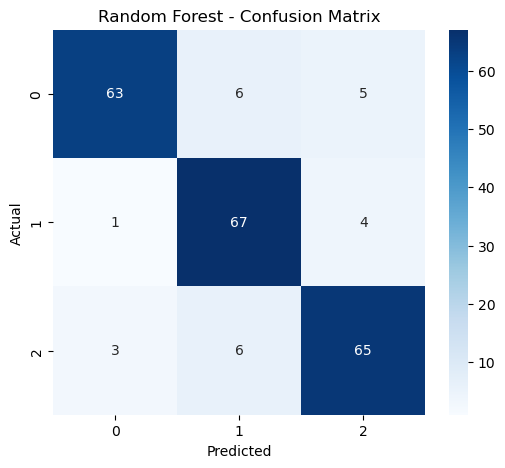

In [46]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

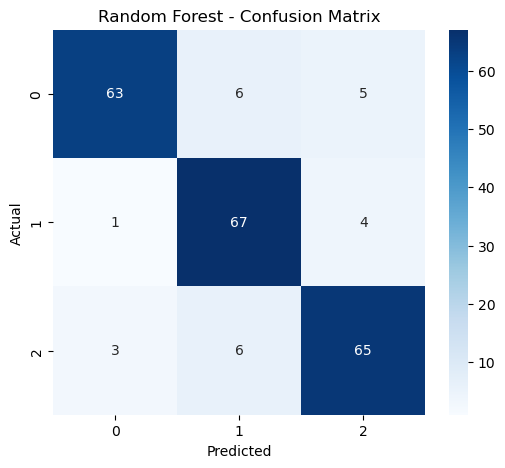

In [47]:
cm = confusion_matrix(y_test, tuned_rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest CV scores:", rf_cv)
print("Mean CV accuracy:", rf_cv.mean(), "Std:", rf_cv.std())

Random Forest CV scores: [0.89772727 0.89204545 0.89772727 0.84090909 0.88636364]
Mean CV accuracy: 0.8829545454545455 Std: 0.02144086620921954


In [49]:
#saving the model
import joblib

In [50]:
joblib.dump(best_rf, "../results/model_trained_files/random_forest_model.pkl")

['../results/model_trained_files/random_forest_model.pkl']